# Order of Accuracy of Finite Difference Formulas

This notebook reads the results produced by the C++ program (`build/results.h5`) and checks that:

- Forward difference $\dfrac{f_{i+1}-f_i}{\Delta x} = f'(x)$ is **first-order accurate**: $\varepsilon \sim O(\Delta x)$
- Central difference $\dfrac{f_{i+1}-f_{i-1}}{2\Delta x} = f'(x)$ is **second-order accurate**: $\varepsilon \sim O(\Delta x^2)$

The test function is $f(x) = \sin(x)$, with exact derivative $f'(x) = \cos(x)$, evaluated at $x_0 = 1.0$.

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

## Load results from HDF5

In [2]:
with h5py.File("build/results.h5", "r") as f:
    dx = f["dx"][:]
    eps_forward = f["err_forward"][:]
    eps_central = f["err_central"][:]

print(f"Loaded {len(dx)} step sizes, from dx={dx[0]:.3e} to dx={dx[-1]:.3e}")

Loaded 15 step sizes, from dx=1.000e-01 to dx=6.104e-06


## Plot $\varepsilon$ vs $\Delta x$ (log-log)

On a log-log plot, an error that behaves like $\varepsilon = C \Delta x^p$ appears as a straight line with slope $p$.
Reference lines of slope 1 and 2 are added for comparison.

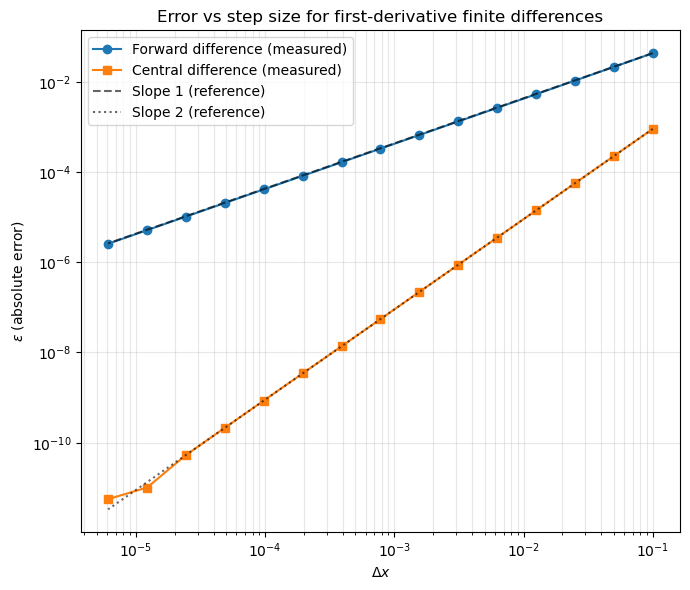

In [3]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.loglog(dx, eps_forward, "o-", label="Forward difference (measured)")
ax.loglog(dx, eps_central, "s-", label="Central difference (measured)")

# Reference slopes, anchored to the first data point of each series
ref_dx = np.array([dx[0], dx[-1]])
ax.loglog(ref_dx, eps_forward[0] * (ref_dx / dx[0]) ** 1, "k--", alpha=0.6, label="Slope 1 (reference)")
ax.loglog(ref_dx, eps_central[0] * (ref_dx / dx[0]) ** 2, "k:", alpha=0.6, label="Slope 2 (reference)")

ax.set_xlabel(r"$\Delta x$")
ax.set_ylabel(r"$\varepsilon$ (absolute error)")
ax.set_title("Error vs step size for first-derivative finite differences")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

## Estimate the observed order of accuracy

For a sequence of step sizes halved at every iteration, the order $p$ is estimated as

$$p = \log_2\left(\frac{\varepsilon(\Delta x)}{\varepsilon(\Delta x / 2)}\right)$$

In [4]:
p_forward = np.log2(eps_forward[:-1] / eps_forward[1:])
p_central = np.log2(eps_central[:-1] / eps_central[1:])

print("dx           p_forward   p_central")
for i in range(len(p_forward)):
    print(f"{dx[i]:<12.3e} {p_forward[i]:<11.4f} {p_central[i]:<11.4f}")

dx           p_forward   p_central
1.000e-01    1.0143      1.9995     
5.000e-02    1.0074      1.9999     
2.500e-02    1.0038      2.0000     
1.250e-02    1.0019      2.0000     
6.250e-03    1.0010      2.0000     
3.125e-03    1.0005      2.0000     
1.563e-03    1.0002      2.0000     
7.813e-04    1.0001      2.0000     
3.906e-04    1.0001      2.0000     
1.953e-04    1.0000      1.9998     
9.766e-05    1.0000      1.9993     
4.883e-05    1.0000      2.0085     
2.441e-05    1.0000      2.3894     
1.221e-05    1.0000      0.8527     


## Conclusion

As $\Delta x$ decreases, `p_forward` converges to **1.0** and `p_central` converges to **2.0**, confirming that the
forward difference is first-order accurate and the central difference is second-order accurate. For the smallest
values of $\Delta x$, floating-point round-off error starts to dominate the truncation error, which is why the
estimated order degrades at the tail of the table/plot — this is expected numerical behavior, not a flaw in the
formulas.